# Agrisubsidy Random Forest + SHAP

This notebook trains a Random Forest classifier using the Agrisubsidy dataset and generates model-based explanations with SHAP.

**Expected Excel columns:**
- Subsidy Type
- Farm Size (ha)
- Average Yield (tons/ha)
- Crop Yield (tons/ha)
- Average Selling Price (₱/kg)
- Feedback Score
- Subsidy Received
- Pest
- Calamity
- Effectiveness Label


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [4]:
# Load dataset
file_path = "datasets/subsidy_dataset2_initial.xlsx"
df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())

Dataset loaded successfully!
Rows: 798
Columns: 10


,Subsidy Type,Farm Size (ha),Average Yield (tons/ha),Crop Yield (bags/ha),Average Selling Price (₱/kg),Feedback Score,Subsidy Received,Pest,Calamity,Effectiveness Label
0,Seed / Soil / Foliar Fertilizer,2.93,6.154111,160.0,20.05,2.7,Yes,Insects,No,Moderately Effective
1,Seed / Foliar Fertilizer,0.80,6.154111,100.0,26.00,3.2,Yes,No,No,Moderately Effective
2,Foliar Fertilizer,2.77,6.154111,170.0,20.12,1.7,Yes,Rats / Kohol,Moderate Flooding,Moderately Effective
3,Seed / Soil Fertilizer,1.23,6.154111,50.0,19.13,1.0,Yes,Rats / Kohol,Drought,Not Effective
4,Soil Fertilizer,3.63,6.154111,180.0,17.33,3.2,Yes,No,Flooding / Pest Damage,Effective


In [5]:
# Inspect dataset
print("COLUMN NAMES")
for column in df.columns:
    print(column)

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

COLUMN NAMES
Subsidy Type
Farm Size (ha)
Average Yield (tons/ha)
Crop Yield (bags/ha)
Average Selling Price (₱/kg)
Feedback Score
Subsidy Received
Pest
Calamity
Effectiveness Label

DATA TYPES
Subsidy Type                        str
Farm Size (ha)                  float64
Average Yield (tons/ha)         float64
Crop Yield (bags/ha)            float64
Average Selling Price (₱/kg)    float64
Feedback Score                  float64
Subsidy Received                    str
Pest                                str
Calamity                            str
Effectiveness Label                 str
dtype: object

MISSING VALUES
Subsidy Type                    0
Farm Size (ha)                  0
Average Yield (tons/ha)         0
Crop Yield (bags/ha)            0
Average Selling Price (₱/kg)    0
Feedback Score                  0
Subsidy Received                0
Pest                            0
Calamity                        0
Effectiveness Label             0
dtype: int64

DUPLICATE ROWS
0


In [6]:
# Clean column names and empty rows
df.columns = df.columns.astype(str).str.strip()
df = df.dropna(how="all")

features = [
    "Subsidy Type",
    "Farm Size (ha)",
    "Average Yield (tons/ha)",
    "Crop Yield (bags/ha)",
    "Average Selling Price (₱/kg)",
    "Feedback Score",
    "Subsidy Received",
    "Pest",
    "Calamity"
]

target = "Effectiveness Label"

missing_columns = [c for c in features + [target] if c not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

X = df[features].copy()
y = df[target].copy()

print("All required columns are available.")

All required columns are available.


In [7]:
# Define feature types
numeric_features = [
    "Farm Size (ha)",
    "Average Yield (tons/ha)",
    "Crop Yield (bags/ha)",
    "Average Selling Price (₱/kg)",
    "Feedback Score"
]

categorical_features = [
    "Subsidy Type",
    "Subsidy Received",
    "Pest",
    "Calamity"
]

# Convert numeric columns
for column in numeric_features:
    X[column] = pd.to_numeric(X[column], errors="coerce")

# Clean categorical columns
for column in categorical_features:
    X[column] = X[column].astype("string").str.strip().fillna("Unknown")

# Clean target and remove invalid target rows
y = y.astype("string").str.strip()
valid = y.notna() & ~y.isin(["", "nan", "None", "<NA>"])

X = X.loc[valid].copy()
y = y.loc[valid].copy()

# Fill missing numeric values with median
for column in numeric_features:
    X[column] = X[column].fillna(X[column].median())

print("Remaining records:", len(y))
print("\nClass distribution:")
print(y.value_counts())

Remaining records: 798

Class distribution:
Effectiveness Label
Moderately Effective    266
Not Effective           266
Effective               266
Name: count, dtype: Int64


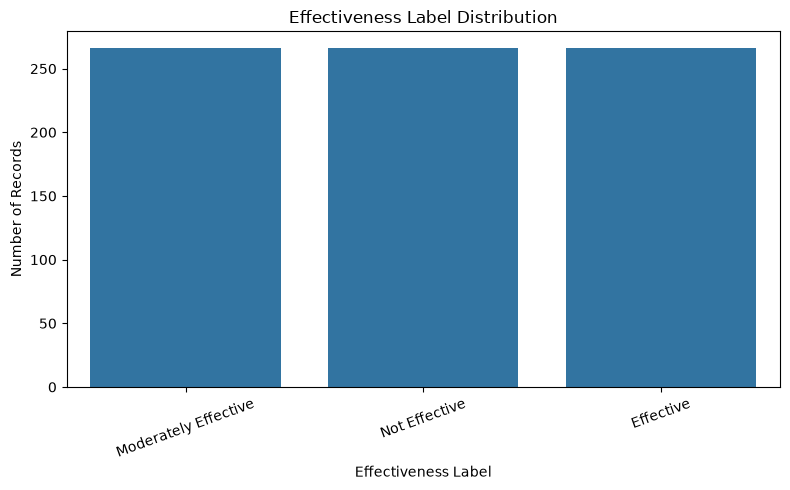

,Farm Size (ha),Average Yield (tons/ha),Crop Yield (bags/ha),Average Selling Price (₱/kg),Feedback Score
count,798.000000,798.000000,798.000000,798.000000,798.000000
mean,2.334023,6.154111,169.532807,20.515977,2.602882
std,1.090466,0.000000,82.962177,2.747597,0.971929
min,0.500000,6.154111,40.000000,14.000000,1.000000
25%,1.470000,6.154111,116.610000,18.627500,1.900000
50%,2.350000,6.154111,155.485000,20.580000,2.600000
75%,3.117500,6.154111,208.410000,22.502500,3.300000
max,5.000000,6.154111,470.000000,26.000000,5.000000


In [8]:
# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=y, order=y.value_counts().index)
plt.title("Effectiveness Label Distribution")
plt.xlabel("Effectiveness Label")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(X[numeric_features].describe())

In [9]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 638
Testing records: 160


In [10]:
# One-hot encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Transformed feature count:", len(feature_names))

Transformed feature count: 28


In [11]:
# Create and train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt",
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train_transformed, y_train)
print("Training completed!")

Training Random Forest...
Training completed!


In [12]:
# Evaluate model
y_pred = rf_model.predict(X_test_transformed)
y_probability = rf_model.predict_proba(X_test_transformed)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")

print("\nClassification Report")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 90.62%
Precision: 91.71%
Recall   : 90.62%
F1 Score : 90.74%

Classification Report
                      precision    recall  f1-score   support

           Effective       0.94      0.94      0.94        53
Moderately Effective       0.81      0.94      0.87        53
       Not Effective       1.00      0.83      0.91        54

            accuracy                           0.91       160
           macro avg       0.92      0.91      0.91       160
        weighted avg       0.92      0.91      0.91       160



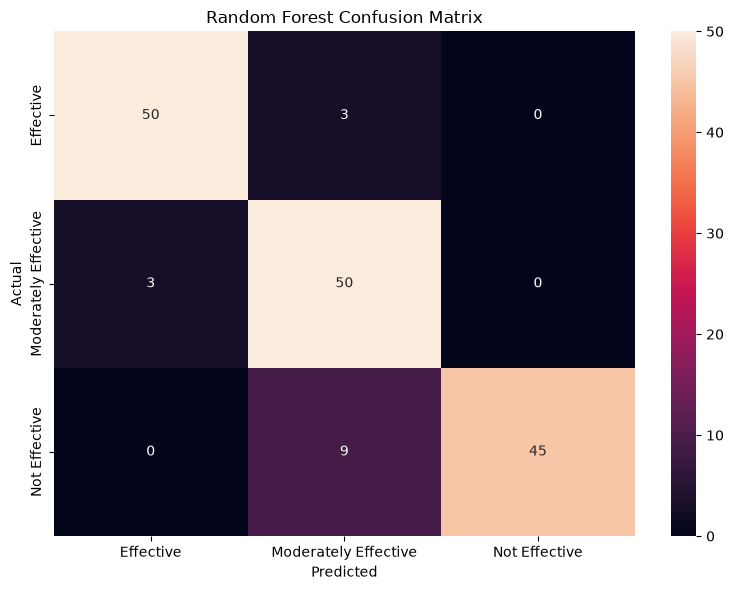

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

,Feature,Importance
25,remainder__Crop Yield (bags/ha),0.409573
27,remainder__Feedback Score,0.246454
23,remainder__Farm Size (ha),0.065434
26,remainder__Average Selling Price (₱/kg),0.062593
11,categorical__Pest_No,0.036548
21,categorical__Calamity_No,0.033068
6,categorical__Subsidy Received_No,0.012393
7,categorical__Subsidy Received_Yes,0.012070
4,categorical__Subsidy Type_Seed / Soil Fertilizer,0.010273
2,categorical__Subsidy Type_Seed / Foliar Fertil...,0.009936


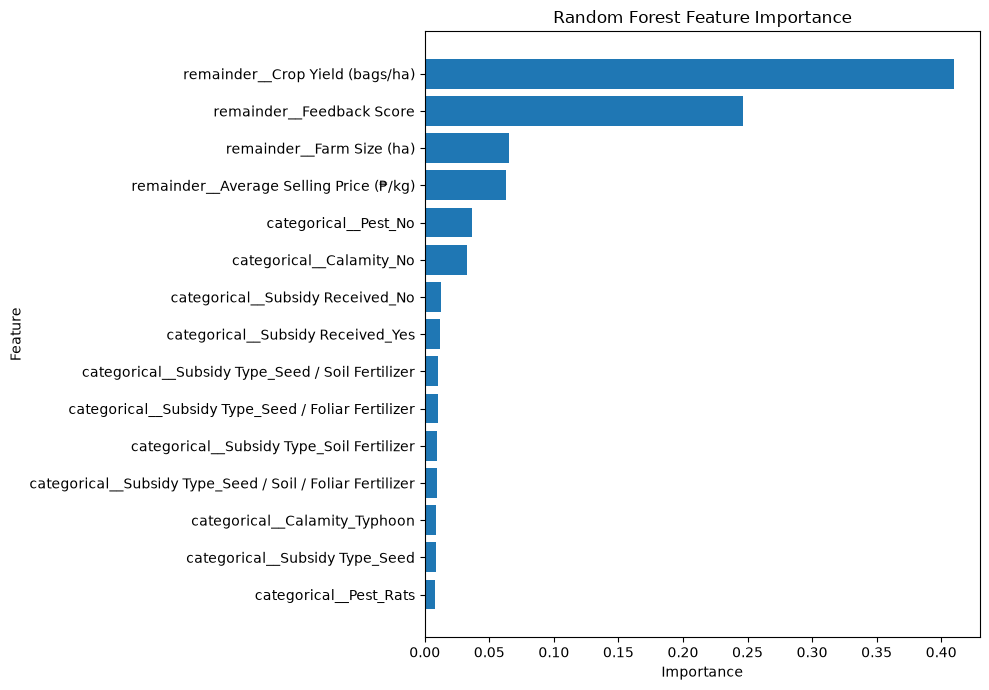

In [14]:
# Feature importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df)

top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [15]:
# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)
print("SHAP explainer created.")

SHAP explainer created.


In [16]:
# Example new farmer record
new_farmer = pd.DataFrame([{
    "Subsidy Type": "Seed",
    "Farm Size (ha)": 2.5,
    "Average Yield (tons/ha)": 4.0,
    "Crop Yield (bags/ha)": 4.8,
    "Average Selling Price (₱/kg)": 25,
    "Feedback Score": 5,
    "Subsidy Received": "Yes",
    "Pest": "No",
    "Calamity": "No"
}])

display(new_farmer)

new_farmer_transformed = preprocessor.transform(new_farmer)

,Subsidy Type,Farm Size (ha),Average Yield (tons/ha),Crop Yield (bags/ha),Average Selling Price (₱/kg),Feedback Score,Subsidy Received,Pest,Calamity
0,Seed,2.5,4.0,4.8,25,5,Yes,No,No


In [17]:
# Predict new farmer
prediction = rf_model.predict(new_farmer_transformed)[0]
probabilities = rf_model.predict_proba(new_farmer_transformed)[0]
classes = rf_model.classes_

probability_dict = dict(zip(classes, probabilities))
confidence = probability_dict[prediction] * 100

print("=" * 60)
print("AGRISUBSIDY EFFECTIVENESS PREDICTION")
print("=" * 60)
print(f"\nPrediction: {prediction}")
print(f"Confidence: {confidence:.2f}%")

print("\nClass Probabilities:")
for label, probability in probability_dict.items():
    print(f"{label}: {probability * 100:.2f}%")

AGRISUBSIDY EFFECTIVENESS PREDICTION

Prediction: Moderately Effective
Confidence: 46.67%

Class Probabilities:
Effective: 26.67%
Moderately Effective: 46.67%
Not Effective: 26.67%


In [18]:
# SHAP values for the new farmer
new_shap_values = explainer.shap_values(new_farmer_transformed)
shap_array = np.asarray(new_shap_values)

predicted_class_index = list(classes).index(prediction)

print("SHAP output shape:", shap_array.shape)

if shap_array.ndim == 3:
    class_shap_values = shap_array[0, :, predicted_class_index]
elif shap_array.ndim == 2:
    class_shap_values = shap_array[0]
else:
    raise ValueError(f"Unexpected SHAP output shape: {shap_array.shape}")

SHAP output shape: (1, 28, 3)


In [19]:
# Create per-prediction feature contribution table
explanation_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": class_shap_values,
    "Absolute Impact": np.abs(class_shap_values)
}).sort_values("Absolute Impact", ascending=False)

display(explanation_df)

,Feature,SHAP Value,Absolute Impact
25,remainder__Crop Yield (bags/ha),0.032101,0.032101
11,categorical__Pest_No,0.023346,0.023346
27,remainder__Feedback Score,0.021039,0.021039
1,categorical__Subsidy Type_Seed,0.020662,0.020662
5,categorical__Subsidy Type_Soil Fertilizer,0.013094,0.013094
6,categorical__Subsidy Received_No,0.009303,0.009303
26,remainder__Average Selling Price (₱/kg),0.007337,0.007337
7,categorical__Subsidy Received_Yes,0.006090,0.006090
3,categorical__Subsidy Type_Seed / Soil / Foliar...,-0.004545,0.004545
20,categorical__Calamity_Moderate Flooding,-0.002643,0.002643


In [20]:
# Generate a dynamic explanation from SHAP contributions
def generate_explanation(prediction, confidence, explanation_df):
    positive = explanation_df[explanation_df["SHAP Value"] > 0].head(3)
    negative = explanation_df[explanation_df["SHAP Value"] < 0].head(3)

    parts = [
        f"The model classified the subsidy as {prediction} "
        f"with {confidence:.2f}% confidence."
    ]

    if len(positive) > 0:
        positive_names = [
            str(f).replace("categorical__", "").replace("remainder__", "")
            for f in positive["Feature"]
        ]
        parts.append(
            "The strongest factors supporting the prediction were "
            + ", ".join(positive_names) + "."
        )

    if len(negative) > 0:
        negative_names = [
            str(f).replace("categorical__", "").replace("remainder__", "")
            for f in negative["Feature"]
        ]
        parts.append(
            "The factors that worked against the prediction were "
            + ", ".join(negative_names) + "."
        )

    return " ".join(parts)

message = generate_explanation(
    prediction,
    confidence,
    explanation_df
)

print("=" * 70)
print("MODEL-BASED EXPLANATION")
print("=" * 70)
print()
print(message)

MODEL-BASED EXPLANATION

The model classified the subsidy as Moderately Effective with 46.67% confidence. The strongest factors supporting the prediction were Crop Yield (bags/ha), Pest_No, Feedback Score. The factors that worked against the prediction were Subsidy Type_Seed / Soil / Foliar Fertilizer, Calamity_Moderate Flooding, Subsidy Type_Seed / Foliar Fertilizer.


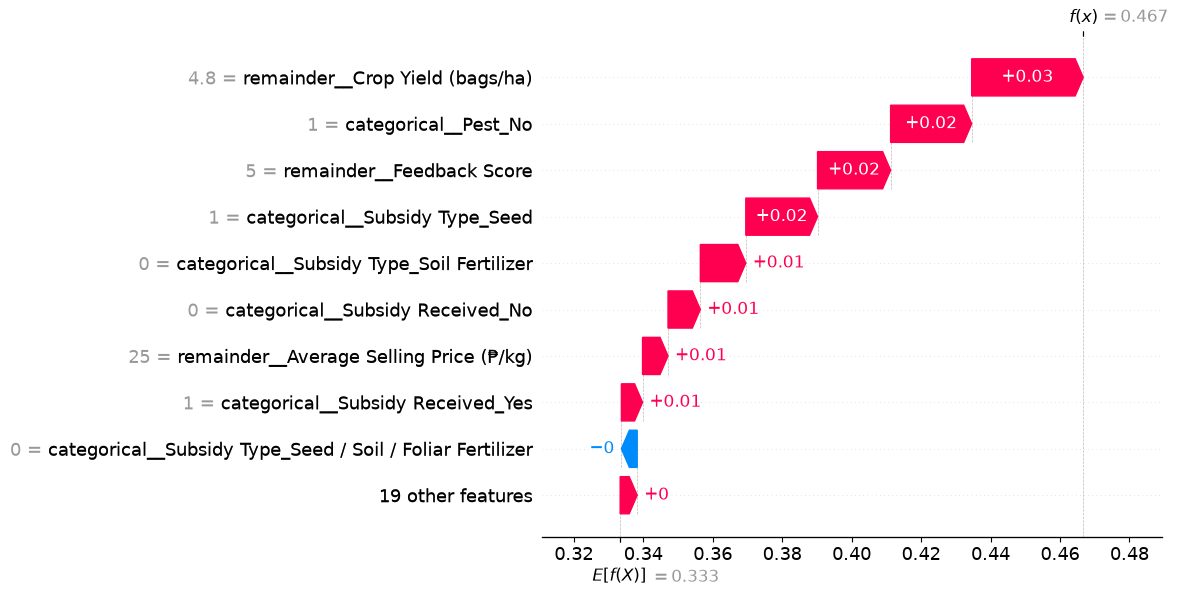

In [21]:
# SHAP waterfall plot
# This visually shows the strongest contributions for this prediction.

expected_value = explainer.expected_value
if np.ndim(expected_value) > 0:
    base_value = expected_value[predicted_class_index]
else:
    base_value = expected_value

shap_explanation = shap.Explanation(
    values=class_shap_values,
    base_values=base_value,
    data=new_farmer_transformed[0],
    feature_names=feature_names
)

shap.plots.waterfall(shap_explanation, max_display=10)

In [22]:
# Save trained model and preprocessing object
joblib.dump(rf_model, "agrisubsidy_random_forest.pkl")
joblib.dump(preprocessor, "agrisubsidy_preprocessor.pkl")

# Save feature importance and explanation
importance_df.to_excel(
    "agrisubsidy_feature_importance.xlsx",
    index=False
)

explanation_df.to_excel(
    "agrisubsidy_shap_explanation.xlsx",
    index=False
)

# Save test predictions
test_results = X_test.copy()
test_results["Actual Effectiveness"] = y_test.values
test_results["Predicted Effectiveness"] = y_pred
test_results["Prediction Confidence (%)"] = np.max(
    y_probability,
    axis=1
) * 100

test_results.to_excel(
    "agrisubsidy_test_predictions.xlsx",
    index=False
)

print("All model files and results saved successfully.")

All model files and results saved successfully.
